## Generating A Blog using user topic

#### START -> BLOG OUTPUT -> GENERATE BLOG -> END ( Prompt Chaining Workflow)

In [27]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_openai import ChatOpenAI

load_dotenv()
model = ChatOpenAI()

### Create a state

In [28]:
class BlogState(TypedDict):
    
    title:str
    outline: str
    content: str

### Graph Define

In [29]:
graph = StateGraph(BlogState)

### Add Nodes

In [30]:
def create_outline(state: BlogState)-> BlogState:
    # fetch the title
    title = state['title']

    # call the llm to generate outline
    prompt = f'Generate a detailed outline for a blog topic {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

def create_blog(state: BlogState)-> BlogState:
    # fetch the outline and title
    title = state['title']
    outline = state['outline']

    # call the llm to generate blog
    prompt = f'Generate detailed blog for {title} using following {outline}'
    content = model.invoke(prompt).content

    # update the state
    state['content'] = content

    return state

graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)

### Add The Edges

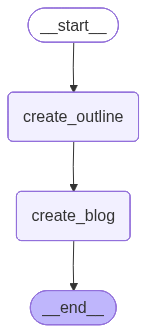

In [31]:
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

graph.compile()

### Compile Graph

In [32]:
workflow = graph.compile()

### Execute Graph

In [26]:
initial_state = {'title':'Raise of AI in India'}
final_state = workflow.invoke(initial_state)
print(final_state['outline'])

I. Introduction
    A. Definition and explanation of AI
    B. Overview of the global rise of AI technology
    C. Focus on the increasing adoption of AI in India

II. History of AI in India
    A. Early developments and research in AI
    B. Key players and institutions driving AI innovation in India
    C. Milestones and advancements in AI technology in India

III. Current state of AI in India
    A. Industries and sectors using AI technology
    B. Government initiatives and support for AI development
    C. Challenges and opportunities for AI adoption in India

IV. Impact of AI on the Indian economy
    A. Job displacement and creation due to AI technology
    B. Potential for economic growth and innovation through AI adoption
    C. Comparison with other countries leading in AI development

V. Ethical and social implications of AI in India
    A. Privacy concerns and data protection in the age of AI
    B. Bias in AI algorithms and its implications for Indian society
    C. Regula

In [33]:
print(final_state['content'])



I. Introduction

Artificial Intelligence (AI) is a revolutionary technology that aims to mimic human intelligence to perform tasks that typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation. The global rise of AI technology has been exponential, with advancements in machine learning, deep learning, natural language processing, and robotics driving innovation across various industries. In India, the adoption of AI technology has been steadily increasing, with businesses and government entities recognizing the potential for economic growth and innovation through AI integration.

II. History of AI in India

India has a rich history of AI research and development, with early developments dating back to the 1980s. Key players and institutions such as the Indian Institute of Technology (IIT) and the Centre for Artificial Intelligence and Robotics (CAIR) have been driving AI innovation in the country. Milestones such a